<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
# import warnings
# warnings.filterwarnings("ignore")
# pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

/content


'/content/drive/MyDrive/CDAC'

# Ridge and Lasso

### Cost Function:
$$
C = \frac{1}{2m} \sum_{i=1}^{m} \left(y_{p_i} - y_{i}\right)^2
$$

- Values of the coeffient in regression are difined in such a way so the value of cost function is minimize.

- When overfitting take place this term is already equal to or near to 0 so penalty term are added.

---

## Penalty Term :
#### 1. Lasso Regression (L1): In lasso regression we add penalty term.
$$
C = \frac{1}{2m} \sum_{i=1}^{m} \left(y_{p_i} - y_{i}\right)^2 + α \sum_{i=1}^{n} |R_j|
$$

- α = Hyperparameter -> we can decide what will be the value.
- value of coeffient can be equal to 0 and so it can be used for feature selection.
- sum of all coefficient of factors

#### 2. Ridge Regression (L2):
$$
C = \frac{1}{2m} \sum_{i=1}^{m} \left(y_{p_i} - y_{i}\right)^2 + α \sum_{i=1}^{n} (R_i)^2
$$
- the coefficient of unimportant can be almost equal to 0
- sum of all coefficient of factors and square of sum


## Standardize required for L1 and L2 to perform?
Unless and until the standardization is perform, L1 and L2 regularization cannot be perform

In [3]:
df = pd.read_excel('StudentData.xlsx')
df = df.drop(['Unnamed: 0'],axis=1)
df.head()

,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
0,7.0,2.9,7.1,2.6,77.0,6.9,5.5,2.2,7.9,2.4,184.7
1,5.7,4.4,5.9,4.2,82.0,8.8,2.2,4.6,5.0,1.6,185.5
2,7.3,4.5,7.6,4.7,85.0,2.2,5.7,1.9,6.2,2.0,189.9
3,9.0,3.8,9.4,4.0,85.2,6.1,6.7,0.9,5.1,3.3,190.5
4,5.5,4.8,5.1,4.8,82.7,3.7,4.8,0.7,5.1,2.2,185.0


In [4]:
# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('Marks', axis=1),df.Marks, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Marks   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     17.96
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.38e-15
Time:                        06:17:18   Log-Likelihood:                -266.22
No. Observations:                  80   AIC:                             554.4
Df Residuals:                      69   BIC:                             580.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
StudyHours        4.9723      2.752      1.807

# MultiCollinearity
- It occur when there are certain pair of input factor which have the very high value correlation coef because of alter/change the effect of the other variable in the model.
- In order to detect multicollinearity, we can calculate VIF(variance inflation factor) Value for each column.
- Ideally VIF should be <10.

In [5]:
df.corr()

,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
StudyHours,1.000000,-0.137275,0.985756,-0.166741,-0.139500,-0.148479,0.039702,-0.119595,-0.116330,0.054158,0.461595
PracticeTests,-0.137275,1.000000,-0.136466,0.982391,0.187605,-0.129208,0.083350,0.098441,0.137525,0.060396,0.455356
RevisionHours,0.985756,-0.136466,1.000000,-0.164784,-0.149062,-0.170147,0.023863,-0.119828,-0.152964,0.079607,0.448704
CoachingHours,-0.166741,0.982391,-0.164784,1.000000,0.230122,-0.115819,0.088085,0.076729,0.100994,0.056112,0.444800
Attendance,-0.139500,0.187605,-0.149062,0.230122,1.000000,-0.090584,0.113714,-0.018171,0.115444,-0.152492,0.430057
MobileUsage,-0.148479,-0.129208,-0.170147,-0.115819,-0.090584,1.000000,-0.086980,0.093279,-0.107880,-0.072796,-0.104220
NetflixHours,0.039702,0.083350,0.023863,0.088085,0.113714,-0.086980,1.000000,-0.106991,0.125457,0.082534,0.140267
GamingHours,-0.119595,0.098441,-0.119828,0.076729,-0.018171,0.093279,-0.106991,1.000000,-0.065969,0.217792,-0.040819
SocialMedia,-0.116330,0.137525,-0.152964,0.100994,0.115444,-0.107880,0.125457,-0.065969,1.000000,-0.212731,0.066168
SportsHours,0.054158,0.060396,0.079607,0.056112,-0.152492,-0.072796,0.082534,0.217792,-0.212731,1.000000,-0.086149


### VIF Value

- we notice the same factor which had a very high corr coef amonst them are also having high VIF value

In [7]:
x = df.drop('Marks', axis=1)

vif_df = pd.DataFrame()
vif_df['Variable'] = x.columns
vif_df['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print("\nVIF VALUES")
print(vif_df.sort_values('VIF', ascending=False))


VIF VALUES
        Variable         VIF
3  CoachingHours  448.533988
1  PracticeTests  444.040942
0     StudyHours  436.685659
2  RevisionHours  407.771297
4     Attendance   60.859442
8    SocialMedia   15.561370
5    MobileUsage    7.811828
9    SportsHours    5.976866
7    GamingHours    5.890728
6   NetflixHours    4.989462


In [8]:
x = df.drop(['Marks', 'CoachingHours', 'StudyHours'], axis=1)

vif_df = pd.DataFrame()
vif_df['Variable'] = x.columns
vif_df['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print("\nVIF VALUES")
print(vif_df.sort_values('VIF', ascending=False))


VIF VALUES
        Variable        VIF
2     Attendance  54.670801
0  PracticeTests  14.844545
6    SocialMedia  13.981452
1  RevisionHours  10.080112
3    MobileUsage   7.657400
7    SportsHours   5.898704
5    GamingHours   5.745141
4   NetflixHours   4.937682


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

x = df.drop('Marks', axis=1)
y=df.Marks
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

from sklearn.linear_model import LinearRegression
regr1 = LinearRegression()
regr1.fit(x_scaled,y)
regr1.coef_
regr1.intercept_
regr1.feature_names_in_

ridge = Ridge(alpha=10)
ridge.fit(x_scaled,y)
ridge.coef_
ridge.intercept_
regr1.feature_names_in_

from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_scaled,y)
print(lassocv.alpha_)

lasso = Lasso(alpha=1)
lasso.fit(x_scaled,y)
lasso.coef_
lasso.intercept_

0.46968573975480105


np.float64(185.09500000000003)

Standardization is only applicable to original column not on dummy column.

# LOGISTIC REGRESSION:

- CASE1:  Binary logistic regression -> 2 possible responses
- CASE2: Nominallogistic regression-> 2 possible level
- CASE3: ordinal logistic regression->LEVELS HAVE LOGICAL ORDER

EVENT OCCUR = P

EVENT NOT OCCURING = 1-P

ODD'S RATIO FOR EVENT TO OCCUR = P / (1-P)
# Binary Logistic Regression


In [4]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        11:24:58   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

In [5]:
df.head()

,Glucose,BloodPressure,Age,DietType,Outcome
0,148,72,50,1,1
1,85,66,31,2,0
2,183,64,32,1,1
3,89,66,21,1,0
4,137,40,33,1,1


# Sigmoid Graph
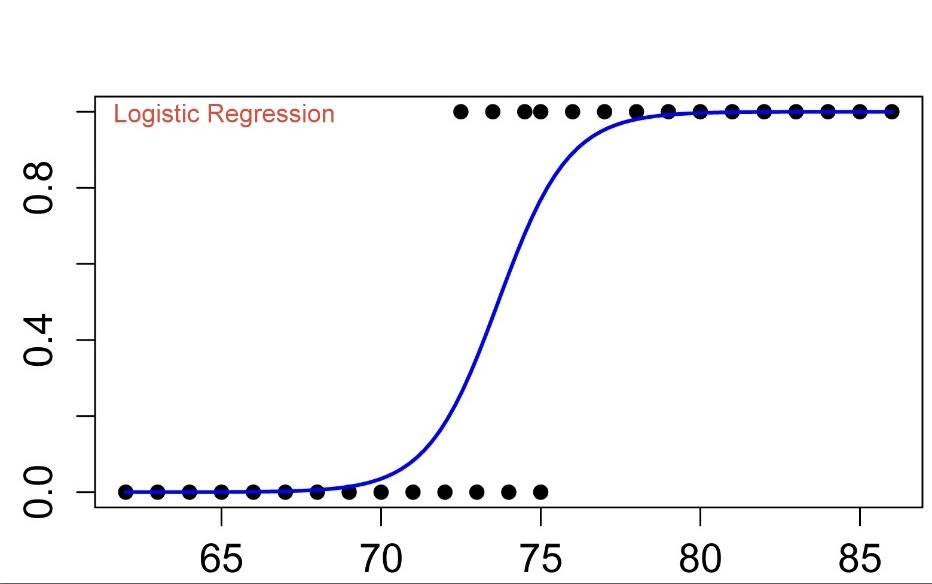

---

Domain: (-inf, inf)

Range: (0,1)

Sigmoid Function :
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$